<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 2 — Clasificación con k-NN y Naive Bayes</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Pima Indians Diabetes** (NIDDK, 1988), un clásico benchmark biomédico que contiene registros de **768 mujeres** con variables metabólicas y demográficas. La variable objetivo es `Outcome` (0 = no diabética, 1 = diabética con diabetes mellitus tipo 2).

Tu misión: construir, evaluar y comparar un clasificador **k-NN** y un **Naive Bayes Gaussiano** para predecir diabetes a partir de variables clínicas. Para cada decisión de diseño deberás **justificar clínicamente** tu elección.

---
> **Dataset:** `diabetes.csv`  
> **Fuente:** Smith, J.W. et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care.  
> Disponible en: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

---

### Variables del dataset

| Variable | Descripción | Unidad |
|---|---|---|
| Pregnancies | Número de embarazos | — |
| Glucose | Glucosa plasmática en ayunas (OGTT 2h) | mg/dL |
| BloodPressure | Presión arterial diastólica | mmHg |
| SkinThickness | Grosor del pliegue tricipital | mm |
| Insulin | Insulina sérica a las 2h | μU/mL |
| BMI | Índice de masa corporal | kg/m² |
| DiabetesPedigreeFunction | Score hereditario de diabetes | — |
| Age | Edad | años |
| **Outcome** | **Diagnóstico de diabetes** | **0/1** |

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — ¿k-NN o Naive Bayes? ¿O ambos?

Para este dataset de variables clínicas continuas, responde **antes de ver los datos**:

1. ¿Qué suposición hace Naive Bayes sobre las features? ¿Es razonable para glucosa, IMC y presión arterial? ¿Por qué?
2. k-NN requiere escalar los datos. Si no lo hicieras, ¿qué feature dominaría la distancia euclidiana y por qué? (pista: revisa las unidades de la tabla)
3. Para un sistema de tamizaje masivo (screening) de diabetes en una posta médica, ¿priorizarías **recall** o **precision**? Argumenta clínicamente.
4. Si la prevalencia de diabetes en la población fuera solo 5% (vs ~35% en este dataset), ¿cómo afectaría eso a la interpretación del posterior de Naive Bayes?

**📝 Tu respuesta (edita esta celda):**
1. Naive Bayes asume independencia condicional entre las variables dado el diagnóstico. No es del todo razonable dado que la glucosa, el indice de masa corporal y presion arterial son marcadores que evaluan la Hiperglicemia, la obesidad y la hipertensión, condiciones que forman parte del sindrome metabólico. En este sindrome, el empeoramiento individual de alguna de las condiciones constituyentes tiende a empeorar las otras. Por ejemplo, un aumento del indice de masa corporal puede conducir a un aumento de la glicemia en ayunas y la presión arterial.
2. Sí, es necesario. Revisando la pagina del dataset https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database, se puede saber que el valor de insulina serica a las 2h puede llegar hasta 846	μU/mL mientras que un valor importante como el DiabetesPedigreeFunction varia entre 0.08 y 2.42. De no escalar las variables, la insulina serica a las 2h dominaría la distancia euclidiana haciendo que valores clave como DiabetesPedigreeFunction tuvieran nulo impacto en el analisis. Por ello, al realizar el escalamiento aseguramos que la importancia pre-analisis de cada indicador sea equitativa.
3. En una estrategia de tamizaje masivo de diabetes se deberia priorizar recall (sensibilidad). Una alta sensibilidad asegura reducir al minimo los falsos negativos (personas enfermas que se les clasifica como sanas). Esto es clave porque una persona enferma que es clasificada como sana puede devenir en un perdida de oportunidad de intervención temprana, lo que aumentará el riesgo de complicaciones tardias como retinopatia diabética, neuropatía diabética o nefropatía diabética. Finalmente, un paciente con complicaciones tardias resultará en menor calidad de vidad, mayor riesgo de mortalidad y mayor gasto para el sistema de salud.
4. Si la prevalencia de diabetes se redujera a solo el 5%, la probabilidad posterior de que un paciente sea diabético se reduciría drasticamente. Esto se debe a que la probabildiad _prior_ es un componente multiplicativo en la fórmula de Bayes. En este escenario, el modelo sería más conservador ya que requeriria evidencias clínicas (Glucosa o resistencia a la insulina) mucho más alta para poder predecir un resultado positivo con confianza.

### 1.2 — Pipeline completo

Dibuja (en texto o diagrama) el pipeline que vas a implementar, indicando **en qué paso** se hace el train/test split y por qué es importante no cruzar esa frontera.

```
diabetes.csv
    │
    ▼
[ Paso A ] Limpieza y analisis de datos  ← ¿Qué haces aquí? -> Identificación de valores nulos (ceros imposibles en Glucose/BMI).
    │
    ▼
[ Paso B ] Train/Test Split  ← ¿Aquí ya haces el split? ¿Por qué? -> Sí, porque evita el Data Leakage, impidiendo que la información del grupo de prueba contamine las estadísticas del entrenamiento.
    │
    ├──────── TRAIN ──────────────────────────────────────────────┐
    │                                                             │
    ▼                                                             │
[ Paso C ] Escalado ← ¿Qué estimas SOLO con train? -> Media y DE  │
    │                                                             │
    ▼                                                             │
[ Paso D ] Entrenamiento  ← Entrenamiento de modelos -> Ajuste de │ k-NN y Naive Bayes con los datos de entrenamiento.                       │
    │                                                             │
    └──────── TEST ── (aplicas lo estimado en C) ─────────────────┘
    │
    ▼
[ Paso E ] Evaluación  ← Evaluación final -> Matriz de confusión, Recall y Curva ROC.
```

**📝 Tu respuesta (edita esta celda):** completa los `___` del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Colores UPCH
UPCH_RED  = '#8B0000'
UPCH_BLUE = '#1565C0'
UPCH_GRAY = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Ruta del dataset
DATA_PATH = Path('/content/drive/MyDrive/ColabNotebooks/ReconocimientoDePatrones/2026_1/Clase2/diabetes.csv')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape: (768, 9)

Primeras filas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Estadísticas descriptivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Paso 2.2 — Distribución de clases y desbalance

Distribución de clases:
  No diabética (0): 500 pacientes (65.1%)
  Diabética    (1): 268 pacientes (34.9%)
[500 268]


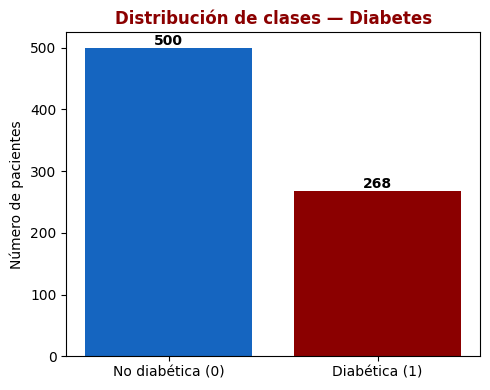

→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula el conteo y porcentaje de cada clase en 'Outcome'
conteo = df['Outcome'].value_counts()
pct    = conteo / len(df) * 100

print('Distribución de clases:')
print(f'  No diabética (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Diabética    (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))

# TODO 2: grafica las barras con colores [UPCH_BLUE, UPCH_RED]
ax.bar(conteo.index, conteo.values, color=[UPCH_BLUE, UPCH_RED])
print(conteo.values)
ax.set_title('Distribución de clases — Diabetes', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabética (0)', 'Diabética (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico y porcentaje encima de cada barra
for x, v in zip(conteo.index, conteo.values):
    ax.text(x, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? ¿Qué clasificador trivial daría accuracy alta sin detectar nada útil?')

Se observa un desbalance moderado en la distribución de clases, con un 65.1% de pacientes no diabéticos y un 34.9% de pacientes diabéticos. En este contexto, un clasificador trivial que prediga siempre la clase mayoritaria (no diabética) alcanzaría una exactitud aparentemente alta (65.1%), pero resultaría clínicamente ineficiente, ya que no lograría identificar correctamente a los pacientes diabéticos.

---
## Ejercicio 3 — Limpieza: valores fisiológicamente imposibles

Este dataset tiene un problema clásico: variables como Glucosa, BloodPressure, BMI e Insulin tienen valores **0** que son fisiológicamente imposibles. Son errores de adquisición codificados como 0 en lugar de `NaN`.

In [ ]:
# Columnas que NO pueden ser 0 fisiológicamente
cols_no_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Valores = 0 por columna (antes de limpiar):')
for col in cols_no_cero:
    n_cero = (df[col] == 0).sum()
    print(f'  {col:<25} {n_cero:>4} ({100*n_cero/len(df):.1f}%)')

Valores = 0 por columna (antes de limpiar):
  Glucose                      5 (0.7%)
  BloodPressure               35 (4.6%)
  SkinThickness              227 (29.6%)
  Insulin                    374 (48.7%)
  BMI                         11 (1.4%)


In [ ]:
df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores 0 por NaN en todas las columnas de cols_no_cero
# Pista: usa un loop o df_clean[cols_no_cero].replace()
df_clean[cols_no_cero] = df_clean[cols_no_cero].replace(0, np.nan)

print('Valores NaN tras limpieza:')
print(df_clean[cols_no_cero].isnull().sum())
print('\n→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.')

Valores NaN tras limpieza:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

→ La imputación se realizará DESPUÉS del split, solo con estadísticas de train.


---
## Ejercicio 4 — EDA: ¿qué features separan mejor las clases?

Antes de entrenar cualquier modelo, exploramos visualmente qué variables tienen más **poder discriminativo**.

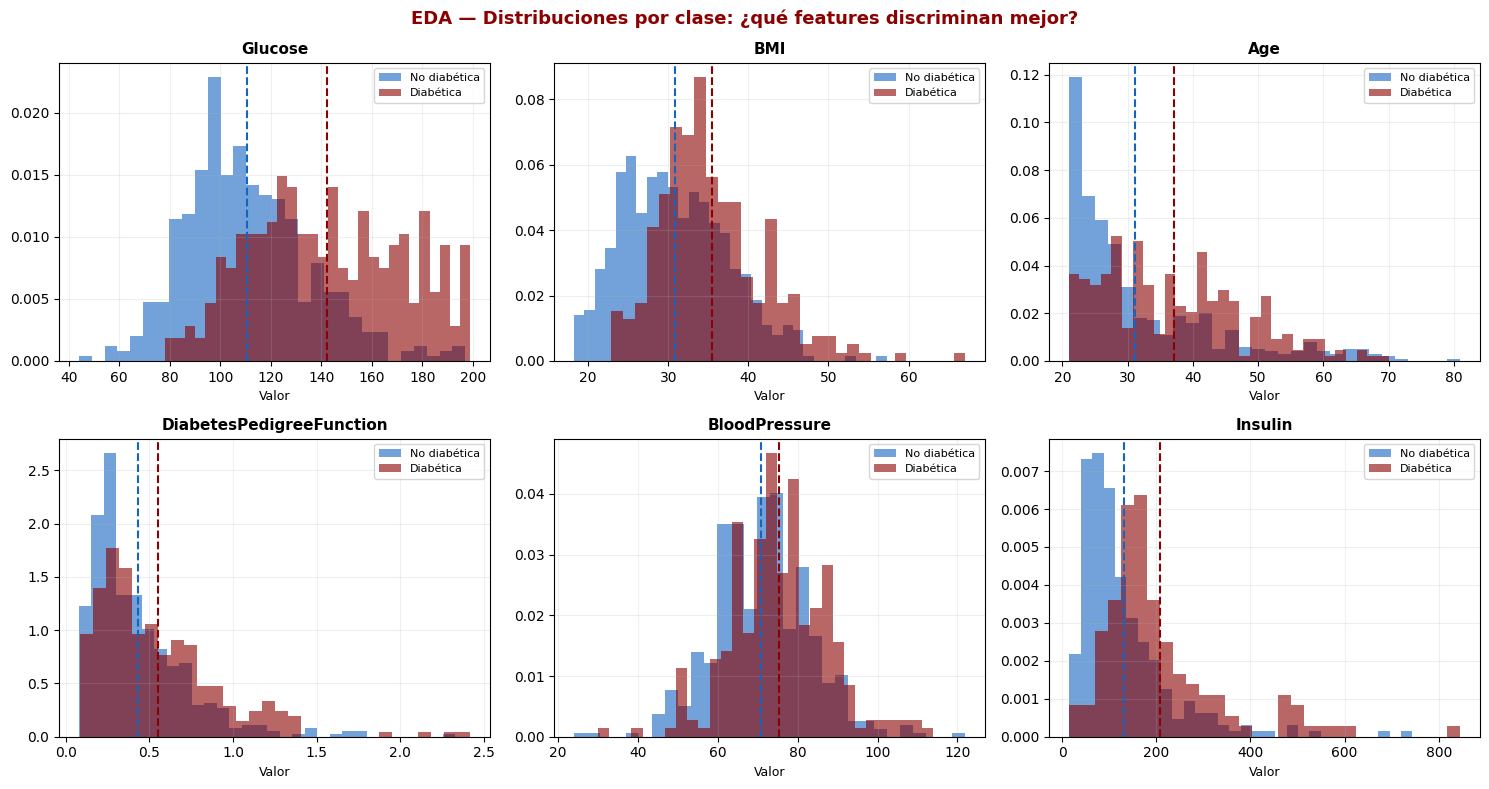

→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?


In [ ]:
features_num = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]

    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos (density=True) para clase 0 y clase 1
    # Usa alpha=0.6, UPCH_BLUE para clase 0, UPCH_RED para clase 1
    # Agrega una línea vertical con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'No diabética'), (1, UPCH_RED, 'Diabética')]:
        valores = df_clean[df_clean['Outcome'] == clase][feat].dropna()
        # TODO: hist y línea de media
        ax.hist(valores, bins=30, density=True, alpha=0.6, color=color, label=label)
        ax.axvline(valores.mean(), color=color, linestyle='--', linewidth=1.5)

    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle('EDA — Distribuciones por clase: ¿qué features discriminan mejor?',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene las distribuciones más separadas? ¿Cuál tiene más solapamiento?')

Se observa que la variable Glucose presenta la mayor capacidad discriminativa, ya que las distribuciones de pacientes diabéticos y no diabéticos muestran una separación más clara, con medias notablemente diferenciadas. En contraste, la variable BloodPressure evidencia un alto grado de solapamiento entre ambas clases, lo que indica una menor capacidad para discriminar entre pacientes diabéticos y no diabéticos.

### Paso 4.2 — Mapa de correlación

Naive Bayes asume independencia condicional. ¿Hay correlaciones fuertes entre features?

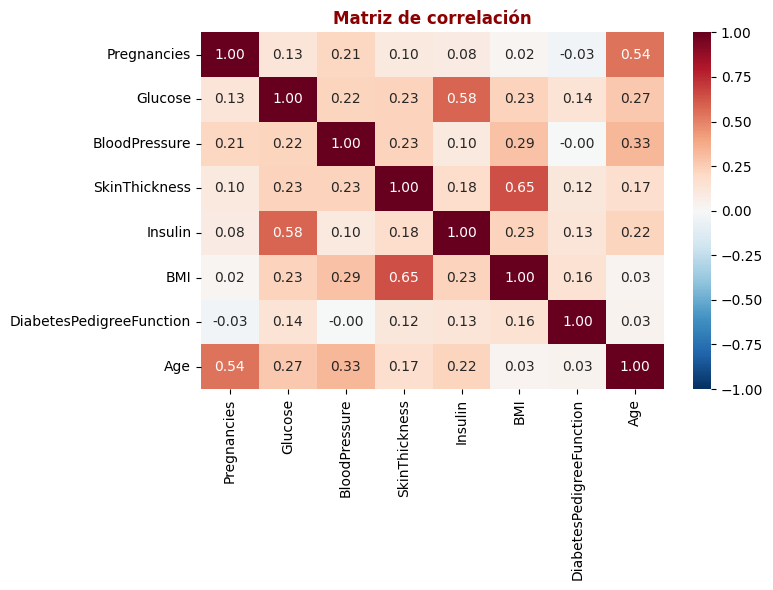

→ Identifica los pares de features con |correlación| > 0.5.
  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula la matriz de correlación de df_clean (solo features numéricas, sin Outcome)
#       y grafícala con seaborn heatmap. Incluye: cmap='RdBu_r', vmin=-1, vmax=1, annot=True

corr = df_clean.drop(columns=['Outcome']).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f')
plt.title('Matriz de correlación', fontweight='bold', color=UPCH_RED)

plt.tight_layout()
plt.show()

print('→ Identifica los pares de features con |correlación| > 0.5.')
print('  ¿Viola esto la suposición de Naive Bayes? ¿Cuánto impacto tendrá?')

Se identifican pares de variables con correlación moderada-alta, como Insulin–Glucose (0.58), Age–Pregnancies (0.54) y SkinThickness–BMI (0.65).

Estas correlaciones sí violan la suposición de independencia condicional del modelo Naive Bayes, ya que este asume que las variables son independientes entre sí dado la clase.

El impacto será moderado ya que no suele degradar drásticamente la exactitud del modelo, pero puede afectar la estimación de probabilidades y generar cierta redundancia en la información (doble conteo de evidencia). Esto puede llevar a decisiones menos precisas en comparación con modelos que sí manejan correlaciones.

---
## Ejercicio 5 — Preprocesamiento: split, imputación y escalado

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: separa features (X) y target (y) de df_clean
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

# TODO 2: haz train_test_split con test_size=0.2, random_state=42, estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  →  {(y_train==1).sum()} diabéticas ({100*(y_train==1).mean():.1f}%)')
print(f'Test:  {X_test.shape}   →  {(y_test==1).sum()} diabéticas ({100*(y_test==1).mean():.1f}%)')

Train: (614, 8)  →  214 diabéticas (34.9%)
Test:  (154, 8)   →  54 diabéticas (35.1%)


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imputa los NaN con la MEDIANA de train (no de todo el dataset)
#       Aplica la mediana de train también al test

mediana_train = X_train.median()
X_train_imp   = X_train.fillna(mediana_train)
X_test_imp    = X_test.fillna(mediana_train)

print(f'NaN en train tras imputación: {np.isnan(X_train_imp).sum()}')
print(f'NaN en test  tras imputación: {np.isnan(X_test_imp).sum()}')

NaN en train tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
NaN en test  tras imputación: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [23]:
# --- COMPLETA EL CÓDIGO ---
# TODO: escala con StandardScaler
#       - fit_transform sobre X_train_imp
#       - transform (sin fit) sobre X_test_imp

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'Train escalado — media: {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')

Train escalado — media: 0.0000  std: 1.0000


---
## Ejercicio 6 — Entrenamiento de modelos

### Paso 6.1 — Naive Bayes Gaussiano

In [24]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con X_train_imp (NB no necesita escalado, usa datos imputados)
gnb = GaussianNB()
gnb.fit(X_train_imp, y_train)

# TODO 2: predice sobre X_test_imp
y_pred_gnb = gnb.predict(X_test_imp)

# TODO 3: imprime accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Naive Bayes — Accuracy: {acc_gnb:.4f}')

Naive Bayes — Accuracy: 0.7013


### Paso 6.2 — k-NN: selección de k óptimo

Entrena k-NN para **k = 1, 3, 5, 7, 9, 11, 15** usando validación interna sobre train (80/20). Grafica train vs val accuracy y selecciona k óptimo.

In [29]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: divide X_train_sc / y_train en subconjuntos train_sub / val (80/20, estratificado)
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_train_sc, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# TODO 2: itera sobre k_values = [1, 3, 5, 7, 9, 11, 15]
#          guarda acc en train_sub y val para cada k
k_values = [1, 3, 5, 7, 9, 11, 15]
acc_tr_list  = []
acc_val_list = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
  knn.fit(X_tr_sub, y_tr_sub)

  acc_tr = accuracy_score(y_tr_sub, knn.predict(X_tr_sub))
  acc_val = accuracy_score(y_val, knn.predict(X_val))

  acc_tr_list.append(acc_tr)
  acc_val_list.append(acc_val)
  print(f'k={k:>2}  →  train: {acc_tr:.4f}   val: {acc_val:.4f}')

# TODO 3: identifica k óptimo (argmax de acc_val_list)
k_optimo = k_values[np.argmax(acc_val_list)]
print(f'k óptimo = {k_optimo}  (val accuracy = {max(acc_val_list):.4f})')



k= 1  →  train: 1.0000   val: 0.6992
k= 3  →  train: 0.8473   val: 0.7642
k= 5  →  train: 0.8126   val: 0.7967
k= 7  →  train: 0.8147   val: 0.7724
k= 9  →  train: 0.7923   val: 0.7642
k=11  →  train: 0.8004   val: 0.7642
k=15  →  train: 0.8004   val: 0.8211
k óptimo = 15  (val accuracy = 0.8211)


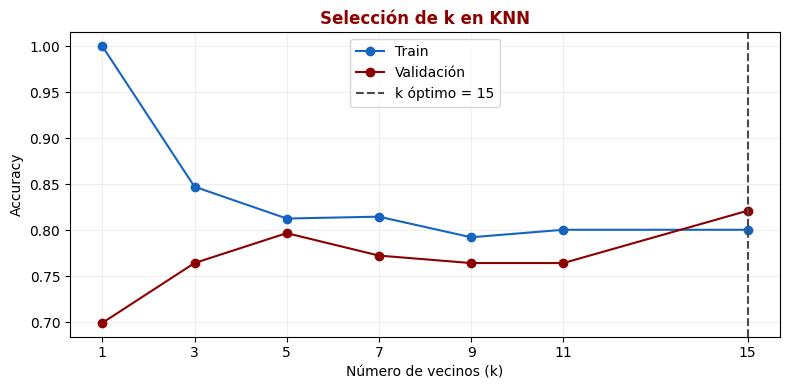

In [30]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica train vs val accuracy en función de k
# Incluye: línea vertical en k óptimo, leyenda, títulos, colores UPCH

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, acc_tr_list, marker='o', color=UPCH_BLUE, label='Train')
ax.plot(k_values, acc_val_list, marker='o', color=UPCH_RED, label='Validación')

ax.axvline(k_optimo, linestyle='--', color=UPCH_GRAY, label=f'k óptimo = {k_optimo}')

ax.set_title('Selección de k en KNN', fontweight='bold', color=UPCH_RED)
ax.set_xlabel('Número de vecinos (k)')
ax.set_ylabel('Accuracy')
ax.set_xticks(k_values)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('knn_seleccion_k_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena k-NN final con k_optimo sobre TODO X_train_sc
#       predice sobre X_test_sc
knn_opt = KNeighborsClassifier(n_neighbors=k_optimo, metric='euclidean', n_jobs=-1)
knn_opt.fit(X_train_sc, y_train)

y_pred_knn = knn_opt.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'k-NN (k={k_optimo}) — Accuracy final en test: {acc_knn:.4f}')

k-NN (k=15) — Accuracy final en test: 0.7403


---
## Ejercicio 7 — Evaluación clínica

### Paso 7.1 — Matrices de confusión lado a lado

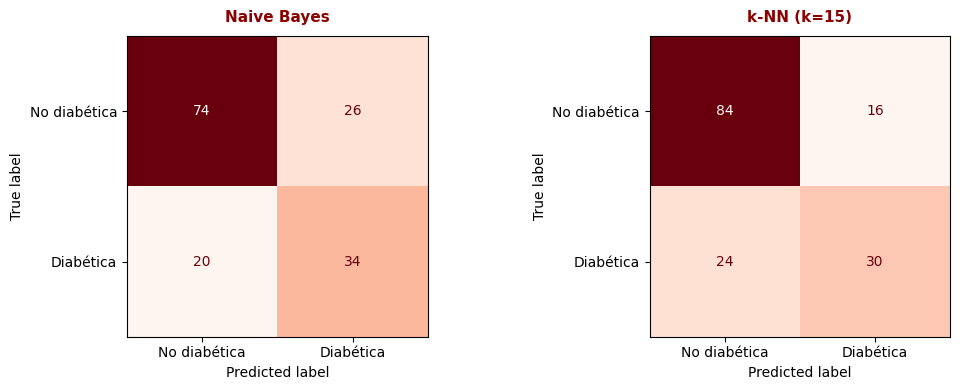

In [33]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica las dos matrices de confusión lado a lado (fig con 2 subplots)
# Usa ConfusionMatrixDisplay, cmap='Reds', labels=['No diabética', 'Diabética']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Naive Bayes
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
ConfusionMatrixDisplay(
    confusion_matrix=cm_gnb,
    display_labels=['No diabética', 'Diabética']
).plot(ax=axes[0], cmap='Reds', colorbar=False)

axes[0].set_title('Naive Bayes',
                  fontsize=11, fontweight='bold', color=UPCH_RED, pad=10)

# k-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['No diabética', 'Diabética']
).plot(ax=axes[1], cmap='Reds', colorbar=False)

axes[1].set_title(f'k-NN (k={k_optimo})',
                  fontsize=11, fontweight='bold', color=UPCH_RED, pad=10)

plt.tight_layout()
plt.savefig('cm_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 7.2 — Tabla de métricas clínicas

In [34]:
# --- COMPLETA EL CÓDIGO ---
# TODO: calcula para ambos modelos: accuracy, precision, recall, f1
#       sobre la clase positiva (Diabética = 1)
#       imprime una tabla comparativa clara

print(f'{"Modelo":<20} {"Accuracy":<10} {"Precision":<10} {"Recall":<10} {"F1-score":<10}')
print('-'*65)

for nombre, y_pred in [('Naive Bayes', y_pred_gnb), (f'k-NN (k={k_optimo})', y_pred_knn)]:
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec  = recall_score(y_test, y_pred, pos_label=1)
    f1   = f1_score(y_test, y_pred, pos_label=1)

    print(f'{nombre:<20} {acc:<10.4f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f}')

print('\n→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?')

Modelo               Accuracy   Precision  Recall     F1-score  
-----------------------------------------------------------------
Naive Bayes          0.7013     0.5667     0.6296     0.5965    
k-NN (k=15)          0.7403     0.6522     0.5556     0.6000    

→ ¿Cuál modelo tiene mayor Recall? ¿Por qué eso importa clínicamente?


El modelo con mayor Recall es Naive Bayes (0.6296), en comparación con k-NN (0.5556).

Esto es clínicamente relevante porque un mayor recall implica una mayor capacidad del modelo para identificar correctamente a los pacientes diabéticos, reduciendo la proporción de falsos negativos. En el ámbito médico, un falso negativo corresponde a un paciente con la enfermedad que no es detectado por el modelo, lo que puede conllevar a la ausencia o retraso en el inicio del tratamiento, incrementando el riesgo de complicaciones y afectando negativamente el pronóstico del paciente.

### Paso 7.3 — Gráfico comparativo de métricas

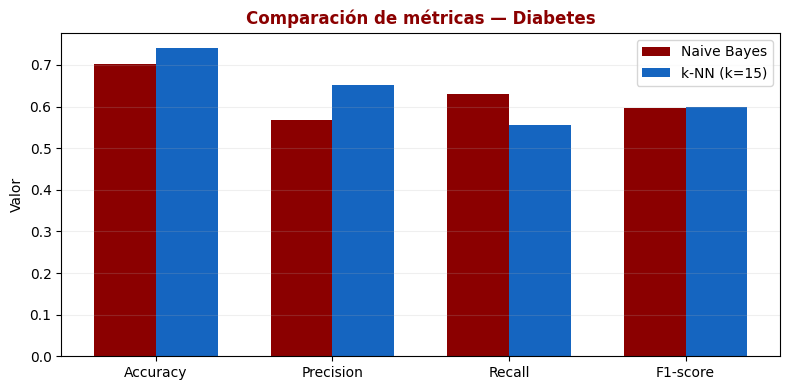

In [35]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica un bar chart comparando accuracy, precision, recall y F1
# para k-NN y Naive Bayes, con colores UPCH

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']

gnb_vals = [
    accuracy_score(y_test, y_pred_gnb),
    precision_score(y_test, y_pred_gnb, pos_label=1),
    recall_score(y_test, y_pred_gnb, pos_label=1),
    f1_score(y_test, y_pred_gnb, pos_label=1)
]

knn_vals = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn, pos_label=1),
    recall_score(y_test, y_pred_knn, pos_label=1),
    f1_score(y_test, y_pred_knn, pos_label=1)
]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width/2, gnb_vals, width, label='Naive Bayes', color=UPCH_RED)
ax.bar(x + width/2, knn_vals, width, label=f'k-NN (k={k_optimo})', color=UPCH_BLUE)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas — Diabetes', fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 8 — Umbral de decisión y probabilidades posteriores

Naive Bayes entrega **probabilidades**, no solo etiquetas. En clínica podemos ajustar el umbral de decisión según el contexto:
- Tamizaje masivo → umbral bajo → maximizar recall (menos FN)
- Confirmación diagnóstica → umbral alto → maximizar precision (menos FP)

Por defecto, scikit-learn usa umbral = 0.5.

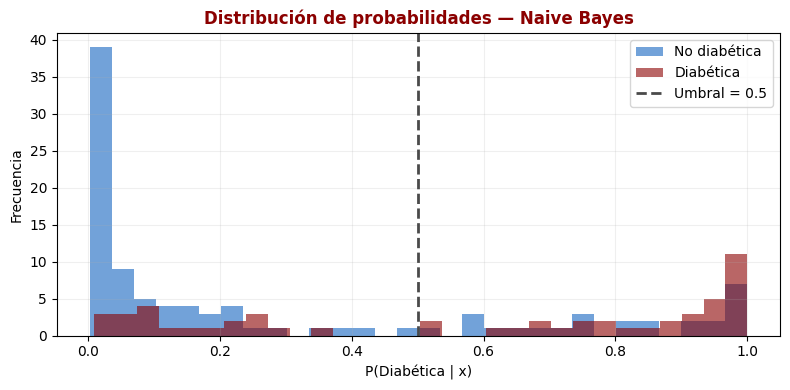

In [37]:
# Probabilidades posteriores de Naive Bayes
proba_gnb = gnb.predict_proba(X_test_imp)[:, 1]  # P(Diabética | x)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: grafica el histograma de probabilidades P(Diabética | x)
#         diferenciando por clase real (y_test == 0 y y_test == 1)
#         con alpha=0.6, UPCH_BLUE y UPCH_RED
#         agrega una línea vertical en 0.5 (umbral por defecto)

fig, ax = plt.subplots(figsize=(8, 4))

# Clase 0
ax.hist(proba_gnb[y_test == 0], bins=30, alpha=0.6, color=UPCH_BLUE, label='No diabética')

# Clase 1
ax.hist(proba_gnb[y_test == 1], bins=30, alpha=0.6, color=UPCH_RED, label='Diabética')

# Línea de umbral
ax.axvline(0.5, color=UPCH_GRAY, linestyle='--', linewidth=2, label='Umbral = 0.5')

ax.set_title('Distribución de probabilidades — Naive Bayes', fontweight='bold', color=UPCH_RED)
ax.set_xlabel('P(Diabética | x)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('histograma_proba.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# --- COMPLETA EL CÓDIGO ---
# TODO 2: evalúa el modelo con umbral = 0.35 (tamizaje) y umbral = 0.65 (confirmación)
#         Compara recall y precision en ambos casos vs el umbral por defecto (0.5)
#         Imprime una tabla con: umbral, precision, recall, F1

print(f'{"Umbral":<10} {"Precision":<10} {"Recall":<10} {"F1-score":<10}')
print('-'*45)

for umbral in [0.35, 0.50, 0.65]:
    y_pred_umbral = (proba_gnb >= umbral).astype(int)

    prec = precision_score(y_test, y_pred_umbral, pos_label=1)
    rec  = recall_score(y_test, y_pred_umbral, pos_label=1)
    f1   = f1_score(y_test, y_pred_umbral, pos_label=1)

    print(f'{umbral:<10.2f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f}')

print()
print('→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,')
print('  qué umbral recomendarías y por qué?')

Umbral     Precision  Recall     F1-score  
---------------------------------------------
0.35       0.5385     0.6481     0.5882    
0.50       0.5667     0.6296     0.5965    
0.65       0.5882     0.5556     0.5714    

→ ¿Para un programa de tamizaje de diabetes en comunidades rurales del Perú,
  qué umbral recomendarías y por qué?


Para un programa de tamizaje en comunidades rurales, se recomendaría un umbral bajo (0.35), ya que permite maximizar el recall (0.6481), es decir, identificar la mayor cantidad posible de pacientes diabéticos. Esto es fundamental en contextos donde el acceso a diagnóstico es limitado, ya que es preferible generar algunos falsos positivos (que luego pueden confirmarse) antes que dejar sin detectar a pacientes con la enfermedad.

---
## Ejercicio 9 — Impacto del Prior (reflexión bayesiana)

El Teorema de Bayes que estudiamos en Clase 1 está en el corazón de Naive Bayes. Ahora lo aplicamos directamente.

In [40]:
# Naive Bayes con prior ajustado manualmente
# Simulamos que estamos en una población con baja prevalencia de diabetes (5%)

# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena un GaussianNB con priors=[0.95, 0.05]
#         (usar parámetro priors= en el constructor)
gnb_low_prev = GaussianNB(priors=[0.95, 0.05])
gnb_low_prev.fit(X_train_imp, y_train)

# TODO 2: predice y calcula recall, precision y accuracy en test
y_pred_lp = gnb_low_prev.predict(X_test_imp)

print('Comparación de priors:')
print(f'  Prior original (~35% diabetes):  Recall={recall_score(y_test, y_pred_gnb):.4f}  Precision={precision_score(y_test, y_pred_gnb):.4f}')
print(f'  Prior 5% diabetes:               Recall={recall_score(y_test, y_pred_lp):.4f}  Precision={precision_score(y_test, y_pred_lp):.4f}')
print()
print('📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?')
print('   Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).')

Comparación de priors:
  Prior original (~35% diabetes):  Recall=0.6296  Precision=0.5667
  Prior 5% diabetes:               Recall=0.3519  Precision=0.6333

📝 Reflexión: ¿Qué le ocurre al recall cuando la prevalencia baja?
   Conecta esto con la Actividad 4 de Clase 1 (Teorema de Bayes).


Cuando la prevalencia de la enfermedad disminuye (de ~35% a 5%), se observa que el recall disminuye significativamente (de 0.6296 a 0.3519). Esto indica que el modelo identifica menos pacientes diabéticos.

Desde el Teorema de Bayes, esto se explica porque la probabilidad previa
𝑃(Diabetes) es mucho menor, lo que reduce la probabilidad posterior
𝑃(Diabetes∣𝑥)
, incluso si la evidencia (los datos del paciente) es similar. Como consecuencia, el modelo se vuelve más conservador y tiende a clasificar más casos como no diabéticos.

En este contexto, aunque la precision aumenta (de 0.5667 a 0.6333), el modelo pierde capacidad para detectar la enfermedad, lo que incrementa los falsos negativos, un aspecto crítico en aplicaciones clínicas.

---
## Ejercicio 10 — Análisis final e interpretación clínica

Responde las siguientes preguntas integrando los resultados obtenidos:

### 10.1 — ¿Cuál modelo elegirías y para qué escenario?

Completa la tabla:

| Escenario | Modelo recomendado | Métrica prioritaria | Justificación |
|---|---|---|---|
| Screening masivo en posta rural | Naive Bayes | Sensibilidad (Recall) | Se prioriza detectar la mayor cantidad de posibles pacientes enfermos.<br> Naive Bayes es más adecuado que k-NN porque es muy rápido en predicción, <br> no necesita almacenar ni comparar con todo el dataset, y funciona bien con <br> pocos recursos computacionales, algo clave en postas rurales. Se prioriza la <br> sensibilidad porque interesa minimizar falsos negativos (no dejar enfermos sin detectar). |
| Confirmación diagnóstica en hospital | k-NN | Especificidad | En hospital se puede usar un modelo más costoso como k-NN, que clasifica según <br> casos similares. Es útil para apoyo diagnóstico, aunque sensible al ruido. Se prioriza <br> la especificidad para reducir falsos positivos y mejorar la precisión clínica. |
| Sistema embebido en glucómetro portátil | Naive Bayes | Sensibilidad + eficiencia computacional | En un dispositivo embebido se necesita un modelo extremadamente ligero. Naive Bayes es <br> mucho más eficiente que k-NN, ya que no requiere calcular distancias con todo el dataset <br> ni almacenar todos los datos,ideal para hardware limitado. Se prioriza la sensibilidad, porque <br> el dispositivo debe evitar pasar por alto casos de riesgo incluso si genera algunos falsos positivos. |

**📝 Tu respuesta (edita esta celda)**

### 10.2 — Limitaciones del análisis

1. ¿Qué asunciones de Naive Bayes se violan en este dataset? ¿Cómo lo detectaste?
2. ¿Por qué k-NN puede ser problemático si el dataset tuviera 50,000 pacientes y 200 features?
3. ¿Qué otra métrica de evaluación sería importante reportar en el contexto clínico?

**📝 Tu respuesta (edita esta celda):**
1. La suposición de independencia condicional entre variables se viola, ya que existen correlaciones moderadas entre algunas features (por ejemplo, Insulin–Glucose, Age–Pregnancies y SkinThickness–BMI). Esto se detectó mediante el análisis de la matriz de correlación, donde se identificaron valores de correlación moderados a altos (por ejemplo, |r| > 0.5 en algunos pares). Esto evidencia que la independencia no se cumple estrictamente, lo que puede afectar la calidad de las probabilidades estimadas por el modelo.

2. k-NN puede volverse problemático en un dataset grande (por ejemplo, 50,000 pacientes y 200 variables) por dos razones principales. En primer lugar, es un algoritmo basado en instancias, lo que significa que para clasificar un nuevo paciente debe calcular la distancia entre ese paciente y todos los datos del entrenamiento. Esto implica un alto costo computacional tanto en tiempo como en memoria, ya que no existe una fase de aprendizaje explícita que reduzca la información.En segundo lugar, en espacios de alta dimensionalidad (muchas variables), ocurre el fenómeno conocido como “maldición de la dimensionalidad”. En este contexto, las distancias entre los puntos tienden a volverse muy similares entre sí, lo que dificulta distinguir correctamente entre vecinos cercanos y lejanos. Como consecuencia, la noción de “vecino más cercano” pierde significado, reduciendo la capacidad del modelo para discriminar entre clases y afectando su rendimiento.

3. La especificidad (true negative rate) sería importante, ya que mide la capacidad del modelo para identificar correctamente a los pacientes sanos. También podría considerarse el AUC-ROC, que evalúa el desempeño del modelo a distintos umbrales de decisión, permitiendo analizar el balance entre sensibilidad y especificidad de forma más completa.

In [41]:
# Resumen ejecutivo final
print('=' * 60)
print('          RESUMEN DEL CHALLENGE 2')
print('=' * 60)
print(f'Dataset: Pima Indians Diabetes  (N={len(df)}, d=8)')
print(f'Prevalencia en test: {100*(y_test==1).mean():.1f}%')
print()
print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 60)

for nombre, y_p in [(f'k-NN (k={k_optimo})', y_pred_knn), ('Naive Bayes', y_pred_gnb)]:
    print(f'{nombre:<20} '
          f'{accuracy_score(y_test, y_p):.4f}       '
          f'{recall_score(y_test, y_p):.4f}       '
          f'{precision_score(y_test, y_p):.4f}       '
          f'{f1_score(y_test, y_p):.4f}')

print()
print('Archivos generados:')
print('  distribucion_diabetes.png   eda_diabetes.png')
print('  knn_seleccion_k_diabetes.png cm_comparacion.png')
print('  comparacion_metricas.png    histograma_proba.png')

          RESUMEN DEL CHALLENGE 2
Dataset: Pima Indians Diabetes  (N=768, d=8)
Prevalencia en test: 35.1%

Modelo               Accuracy     Recall       Precision    F1
------------------------------------------------------------
k-NN (k=15)          0.7403       0.5556       0.6522       0.6000
Naive Bayes          0.7013       0.6296       0.5667       0.5965

Archivos generados:
  distribucion_diabetes.png   eda_diabetes.png
  knn_seleccion_k_diabetes.png cm_comparacion.png
  comparacion_metricas.png    histograma_proba.png
